#### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

####  1: Load the Data

In [2]:
dataset = pd.read_csv('retail_sales_dataset.csv')
dataset.columns = dataset.columns.str.strip()

print("--- First 5 Rows of the Dataset ---")
print(dataset.head(), "\n")

--- First 5 Rows of the Dataset ---
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100   




#### 2. Taking care of missing data

In [4]:
dataset = dataset.dropna(subset=['Customer ID'])
# Initialize the Scikit-Learn Imputers
num_imputer = SimpleImputer(missing_values=np.nan, strategy='median')
cat_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

if 'Price' in dataset.columns:
    dataset[['Price']] = num_imputer.fit_transform(dataset[['Price']])
if 'Quantity' in dataset.columns:
    dataset[['Quantity']] = num_imputer.fit_transform(dataset[['Quantity']])

# Impute missing categories (categorical column)
if 'Category' in dataset.columns:
    dataset[['Category']] = cat_imputer.fit_transform(dataset[['Category']])

print("Missing values remaining:", dataset.isnull().sum().sum(), "\n")

Missing values remaining: 0 




#### 3. Feature Engineering & Calculations

In [8]:
# Calculate Total Revenue per transaction
dataset['Revenue'] = dataset['Quantity'] * dataset['Price per Unit']

# 3a. Compute total revenue by product category
# FIX: Change 'Category' to match your actual column name (e.g., 'Product Category')
revenue_by_category = dataset.groupby('Product Category')['Revenue'].sum().reset_index()
print("--- Total Revenue by Product Category ---")
print(revenue_by_category, "\n")

# 3b. Identify the top 10 customers
top_10_customers = dataset.groupby('Customer ID')['Revenue'].sum().nlargest(10).reset_index()
print("--- Top 10 Customers ---")
print(top_10_customers, "\n")

--- Total Revenue by Product Category ---
  Product Category   Revenue
0           Beauty  143515.0
1         Clothing  155580.0
2      Electronics  156905.0 

--- Top 10 Customers ---
  Customer ID  Revenue
0     CUST015   2000.0
1     CUST065   2000.0
2     CUST072   2000.0
3     CUST074   2000.0
4     CUST089   2000.0
5     CUST093   2000.0
6     CUST109   2000.0
7     CUST118   2000.0
8     CUST124   2000.0
9     CUST139   2000.0 




#### 4. Visualizing Monthly Sales Trend


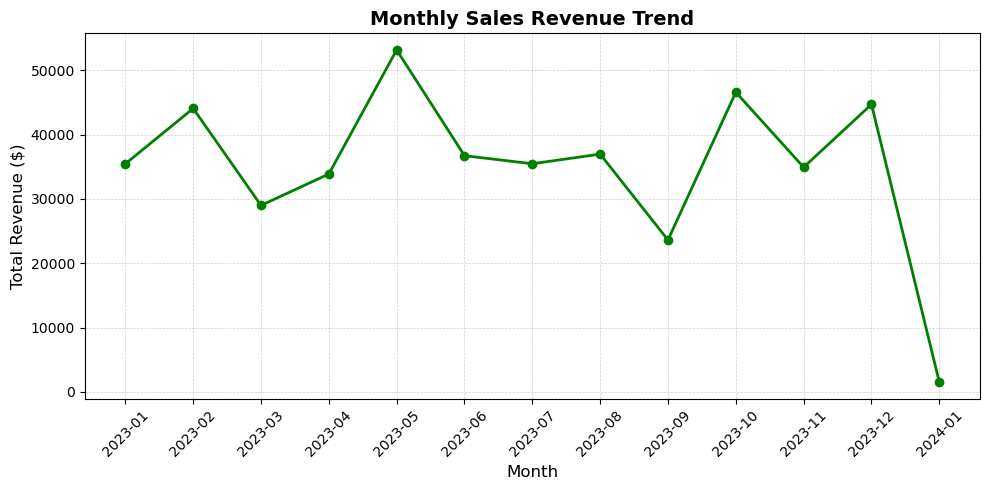

In [9]:
# Convert Date to datetime format and group by month
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset['Month'] = dataset['Date'].dt.to_period('M')

monthly_sales = dataset.groupby('Month')['Revenue'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str) # Convert to string for plotting compatibility

# Plotting the Line Chart
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['Month'], monthly_sales['Revenue'], marker='o', color='g', linestyle='-', linewidth=2)

# Chart styling
plt.title('Monthly Sales Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Render the plot
plt.tight_layout()
plt.show()